<a href="https://colab.research.google.com/github/SousaValentyna/MyMeow2/blob/main/trabalho2_pds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Importação de bibliotecas e montagem do Google Drive

In [9]:
import numpy as np            # Biblioteca para manipulação de arrays numéricos
import pandas as pd           # Biblioteca para manipulação de dados em formato tabular (DataFrame)
import matplotlib.pyplot as plt  # Biblioteca para visualização de gráficos
import os                     # Biblioteca para manipulação de diretórios e arquivos
import random                 # Biblioteca para gerar seleções aleatórias
from scipy.signal import firwin, butter, filtfilt  # Funções para filtros digitais (FIR e IIR)
from scipy.fft import fft, fftfreq  # Funções para análise de Fourier
from google.colab import drive  # Para acessar o Google Drive no ambiente Colab

# Monta o Google Drive
drive.mount('/content/drive')
# A função drive.mount é utilizada para montar o Google Drive no ambiente do Colab, permitindo acessar arquivos armazenados no seu Google Drive.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 2. Definindo o caminho da pasta e listando arquivos CSV

In [10]:
caminho_pasta = '/content/drive/MyDrive/test'  # Ajuste se o nome for outro
arquivos_csv = [f for f in os.listdir(caminho_pasta) if f.endswith('.csv')]
# Lista de arquivos CSV na pasta

# 3. Selecionando arquivos aleatórios ou todos

In [11]:
n_arquivos = len(arquivos_csv)
if n_arquivos >= 10:
    arquivos = random.sample(arquivos_csv, 10)
else:
    arquivos = arquivos_csv

print("Arquivos selecionados:", arquivos)

Arquivos selecionados: ['seg_19b9dd.csv', 'seg_a6bf91.csv', 'seg_932828.csv', 'seg_2ba79a.csv', 'seg_7a9228.csv', 'seg_83dc2e.csv', 'seg_4a6096.csv', 'seg_fb00b3.csv', 'seg_afca81.csv', 'seg_c267a5.csv']


# 4. Normalizando os sinais e criando os filtros

In [12]:
def normalizar(sinal):
    return (sinal - np.mean(sinal)) / np.std(sinal)

fs = 20000  # Frequência de amostragem (20kHz)

# FIR Passa-baixa
ordem_fir = 101
fc_fir = 3000
fir = firwin(ordem_fir, fc_fir, fs=fs)

# IIR Passa-alta
ordem_iir = 4
fc_iir = 3000
b, a = butter(ordem_iir, fc_iir, btype='high', fs=fs)

# 5. Processamento e visualização dos sinais

Processando: seg_19b9dd.csv


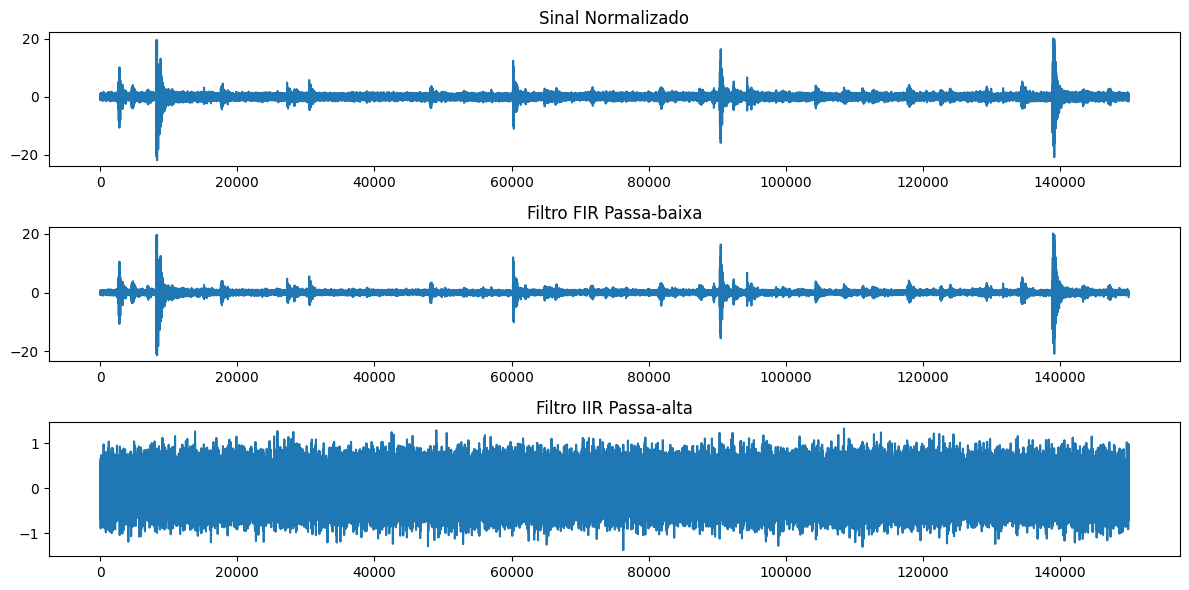

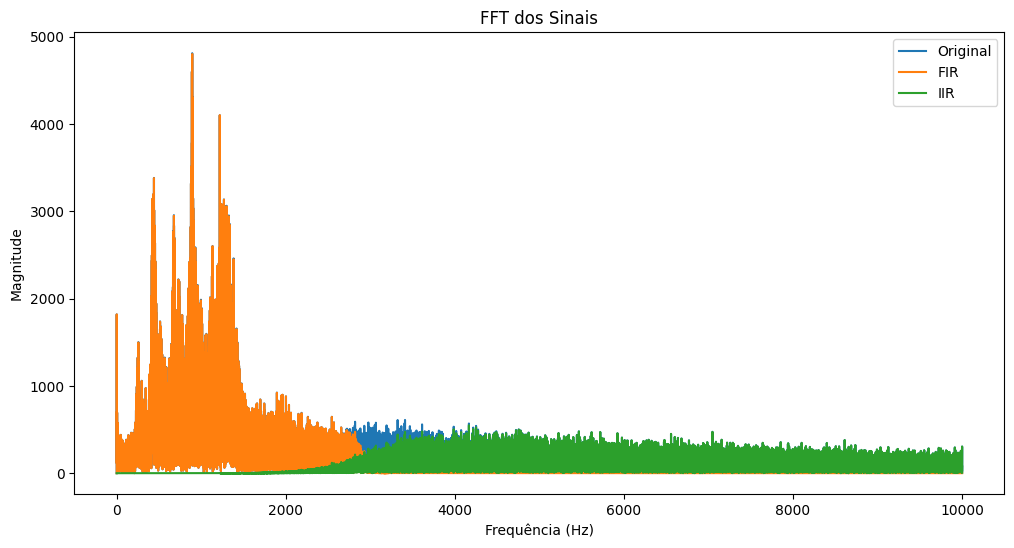

Processando: seg_a6bf91.csv


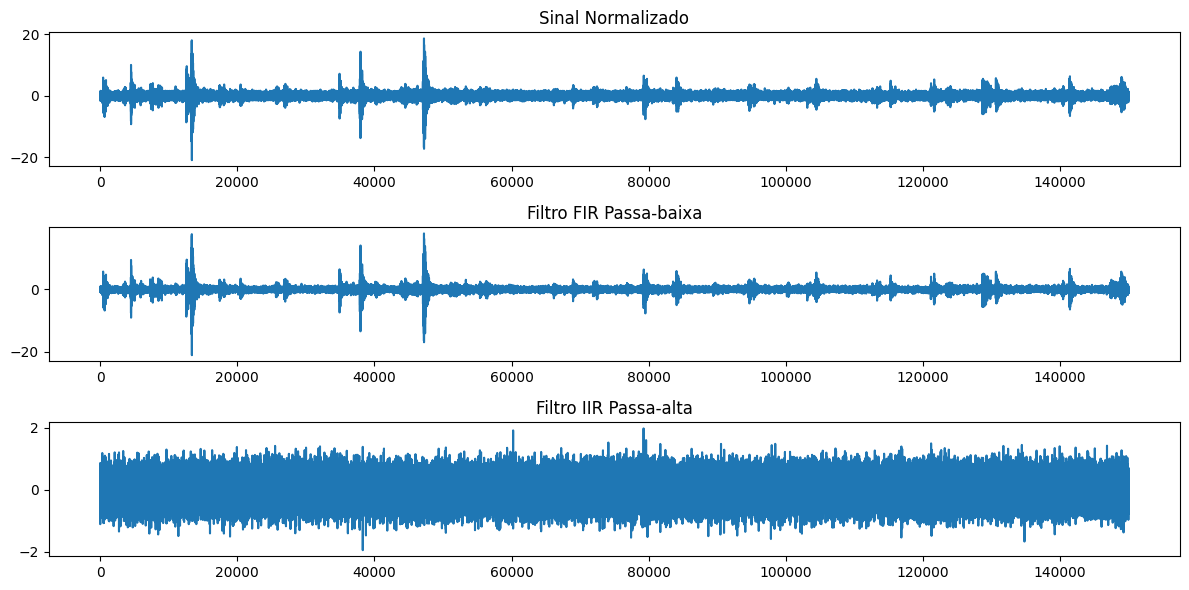

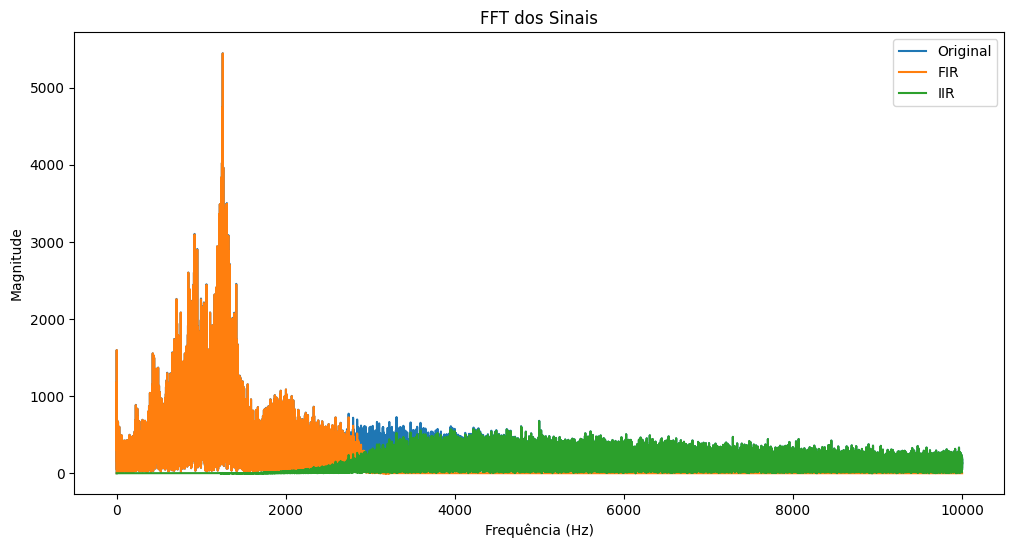

Processando: seg_932828.csv


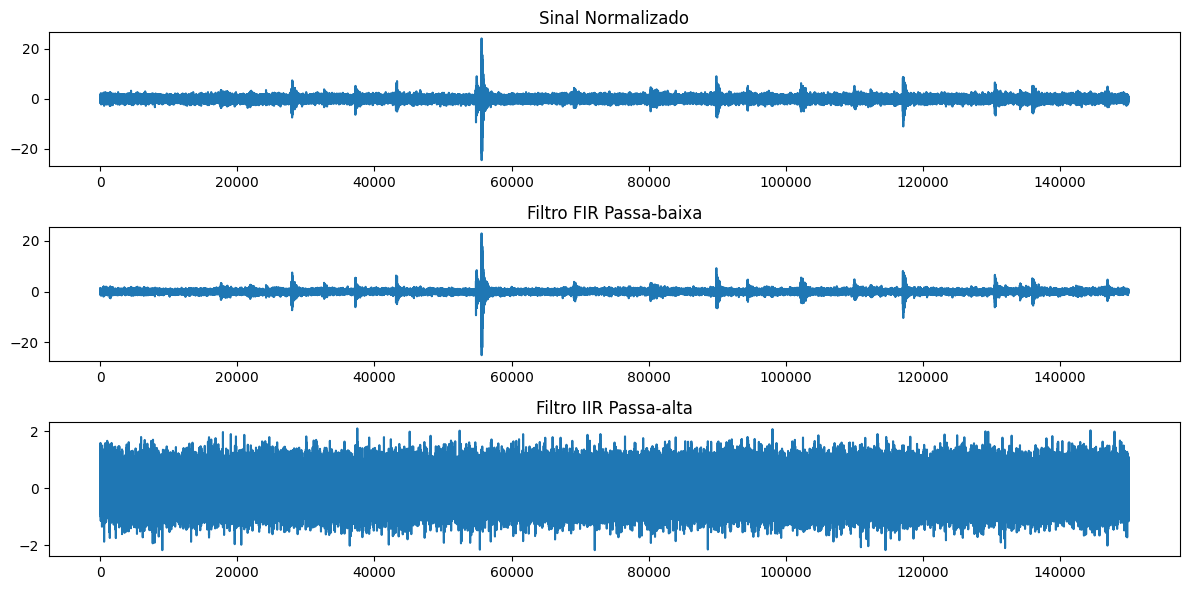

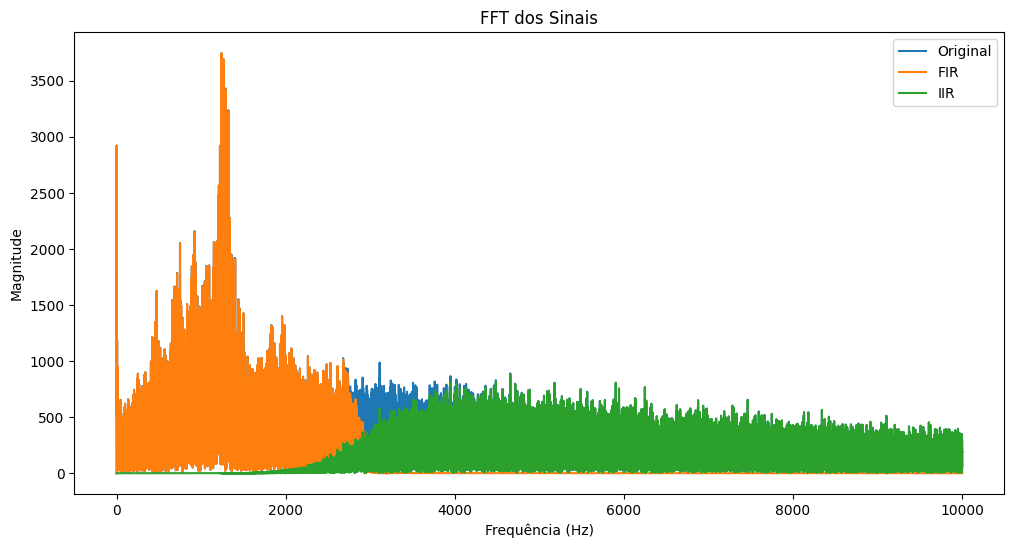

Processando: seg_2ba79a.csv


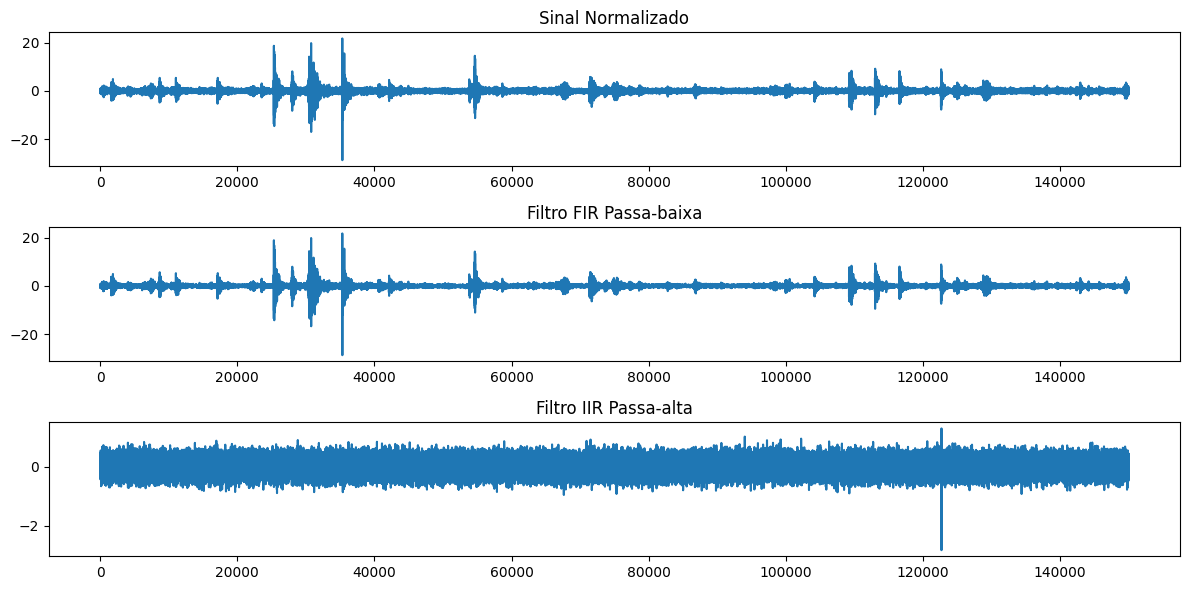

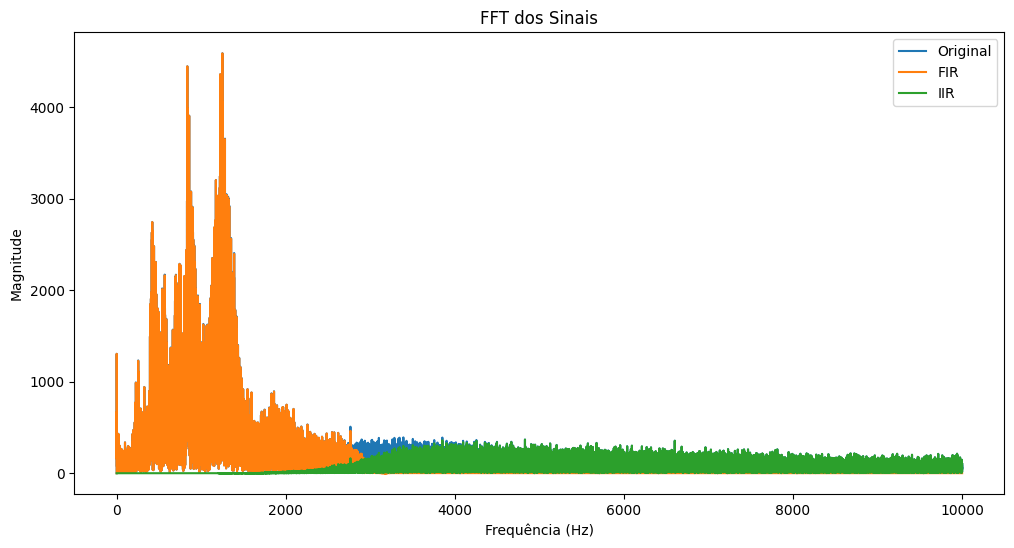

Processando: seg_7a9228.csv


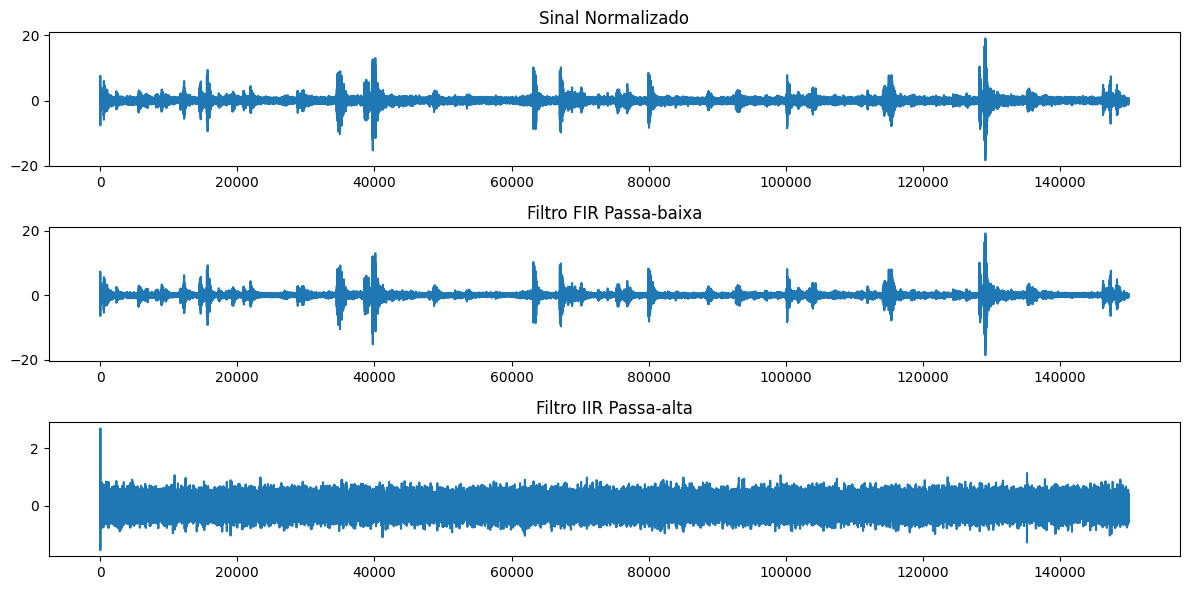

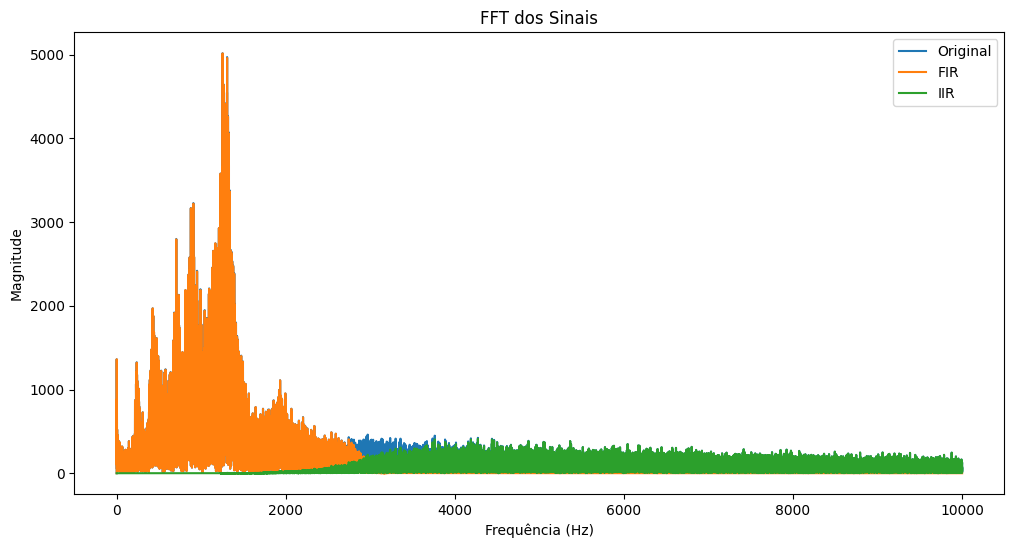

Processando: seg_83dc2e.csv


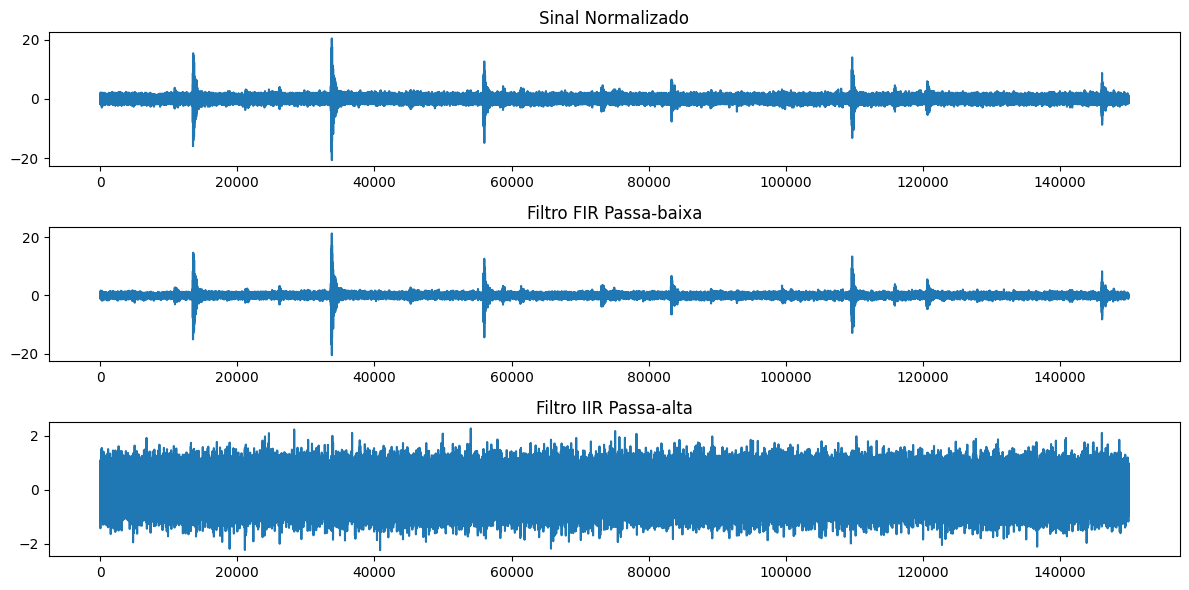

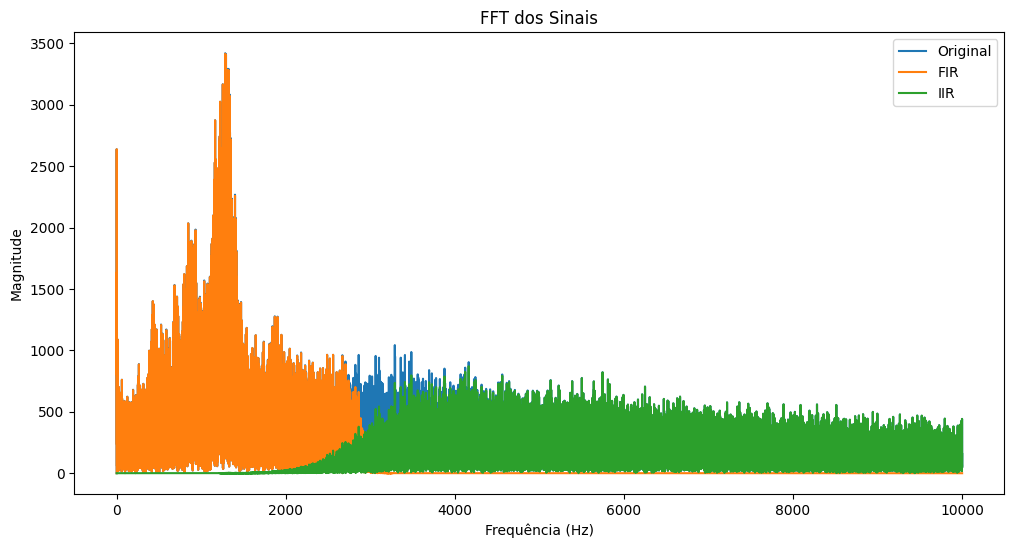

Processando: seg_4a6096.csv


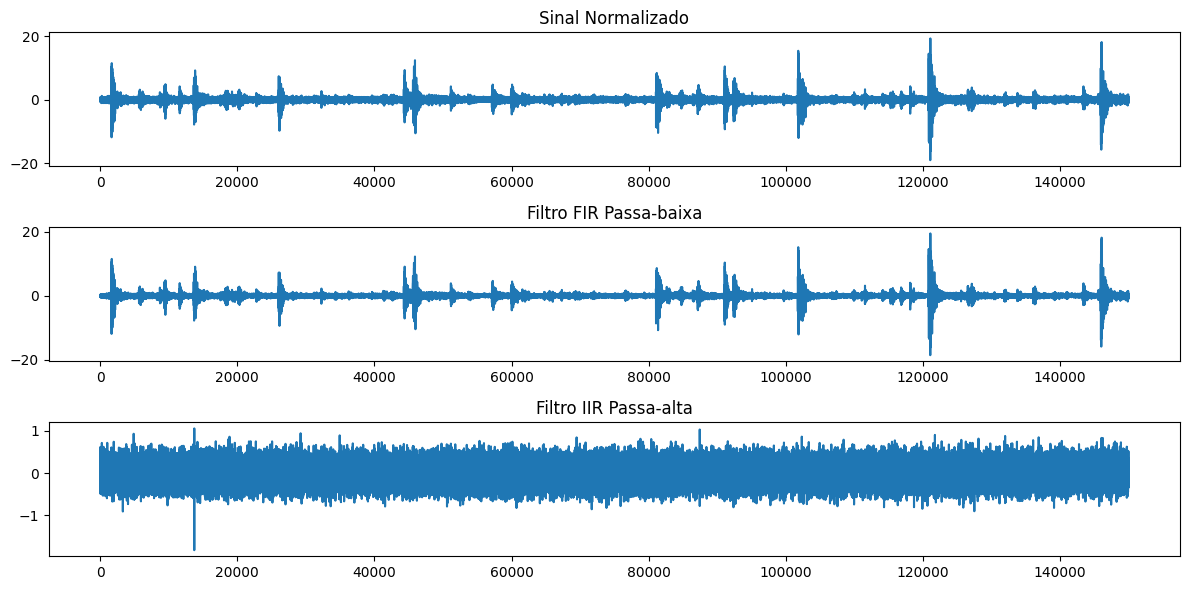

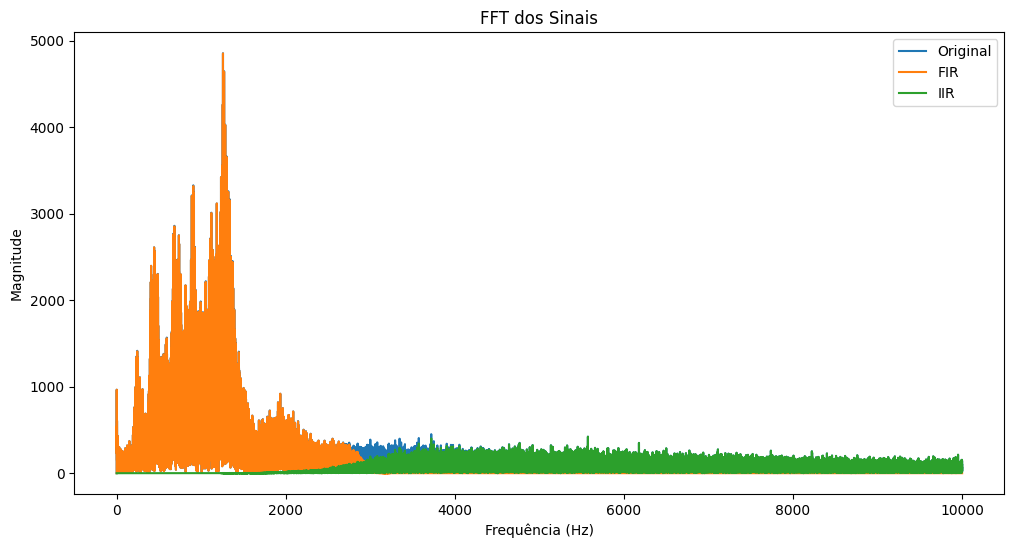

Processando: seg_fb00b3.csv


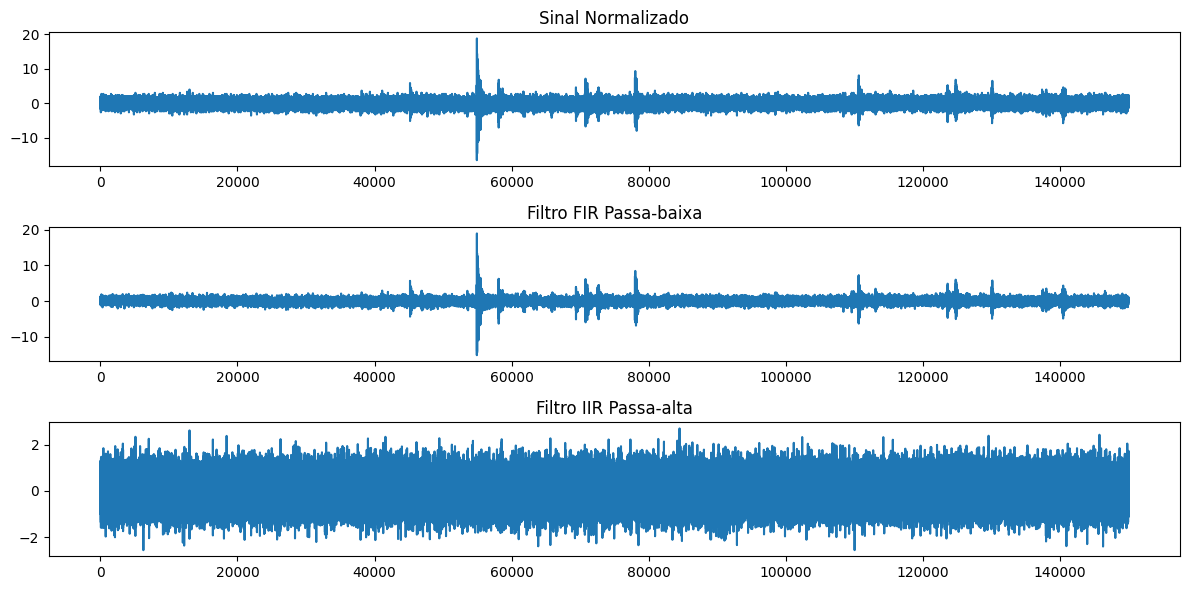

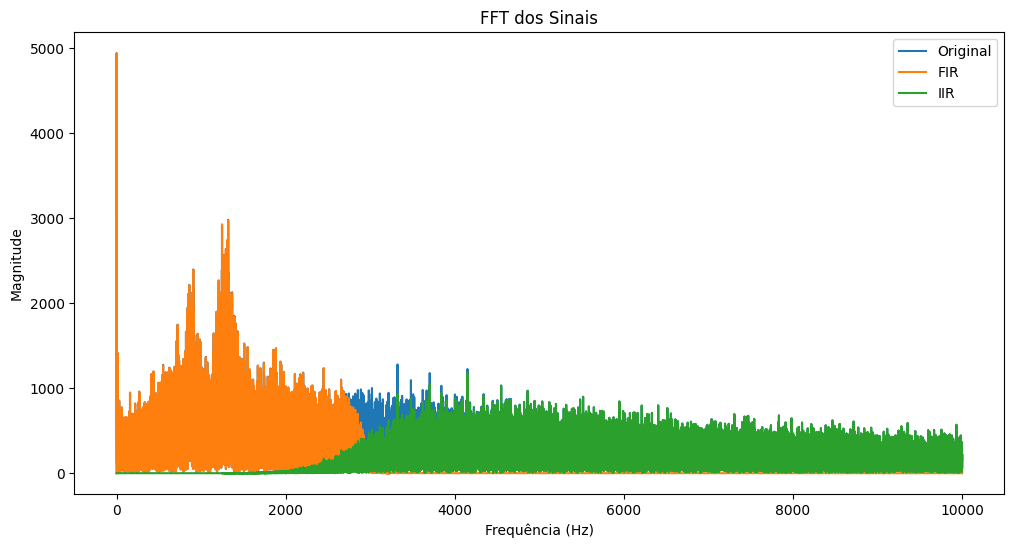

Processando: seg_afca81.csv


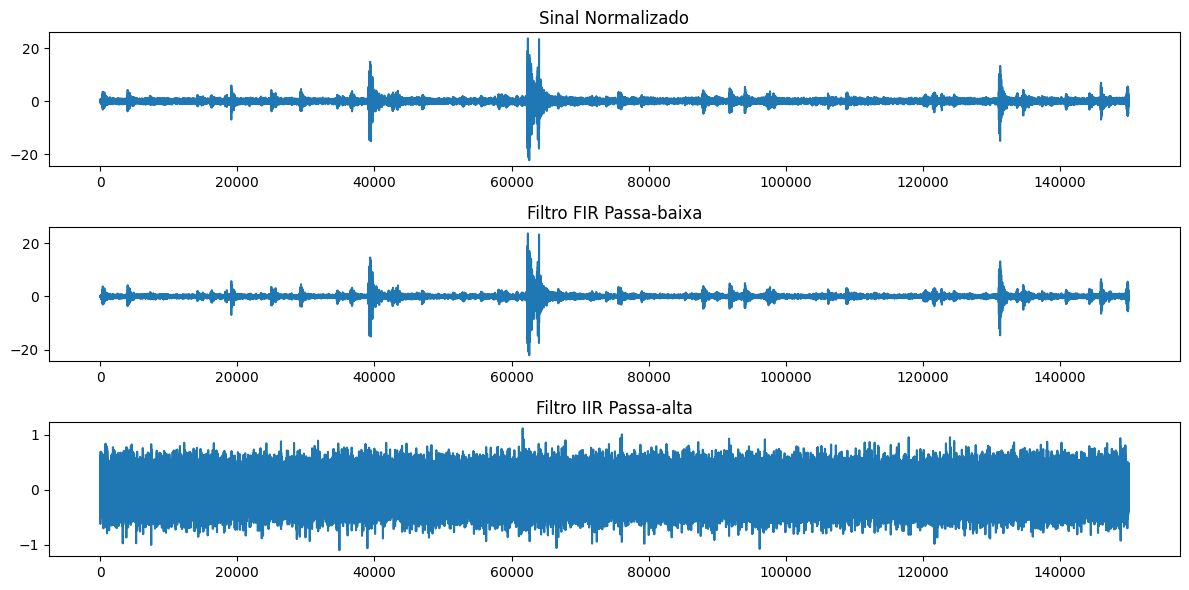

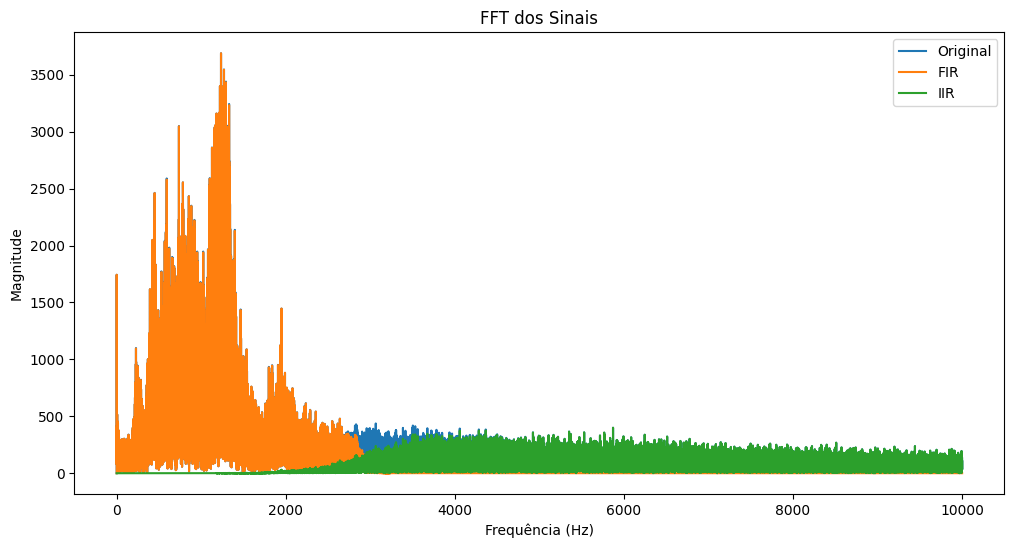

Processando: seg_c267a5.csv


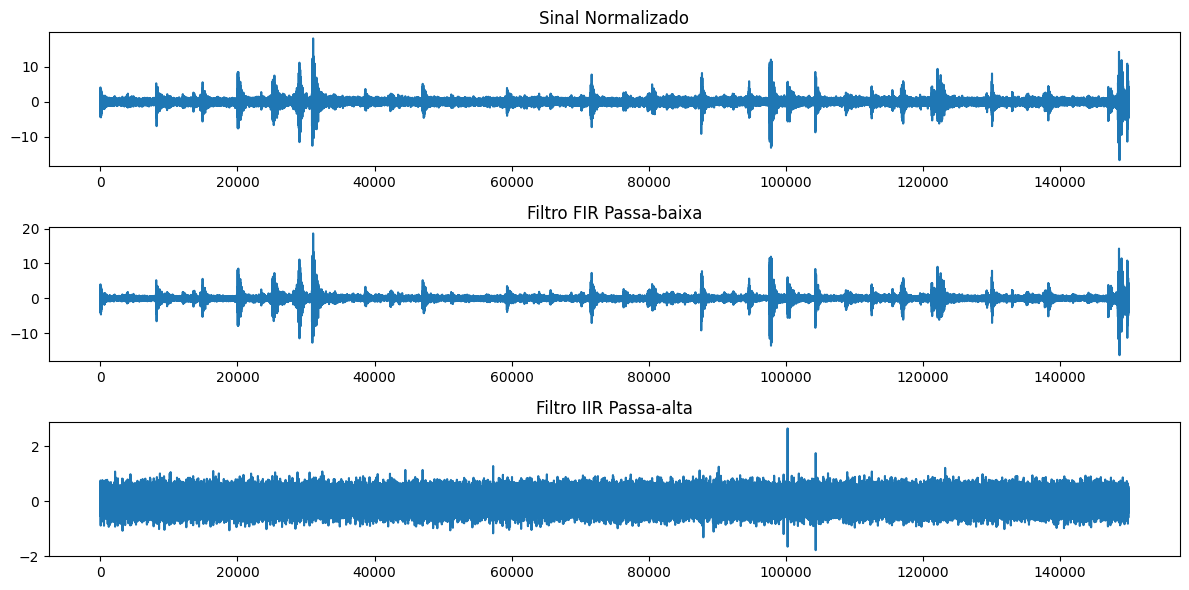

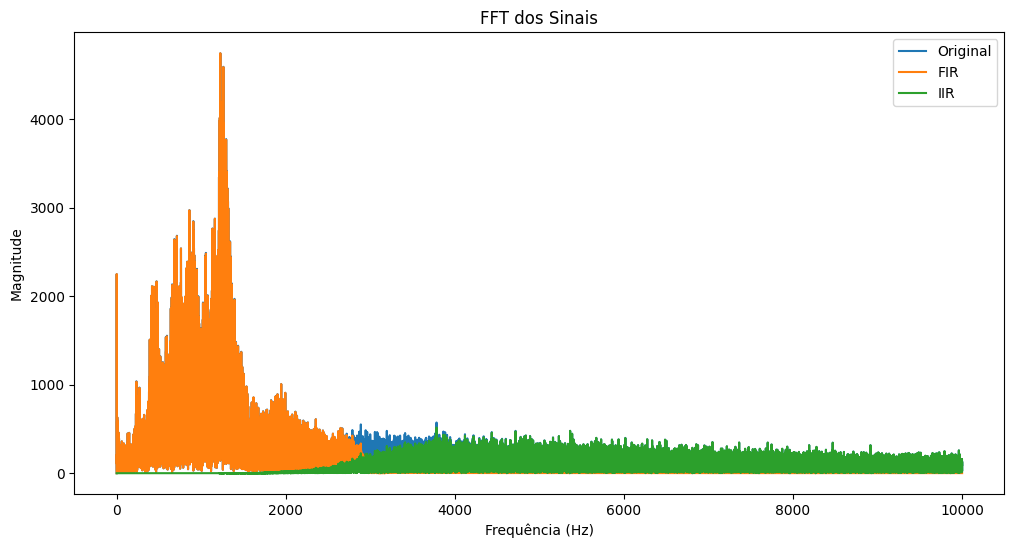

In [13]:
for nome in arquivos:
    print(f"Processando: {nome}")
    path = os.path.join(caminho_pasta, nome)
    df = pd.read_csv(path)
    sinal = df['acoustic_data'].values
    sinal = normalizar(sinal)

    # Filtragens
    sinal_fir = filtfilt(fir, [1], sinal)
    sinal_iir = filtfilt(b, a, sinal)

    # FFT
    N = len(sinal)
    freq = fftfreq(N, 1/fs)
    fft_original = np.abs(fft(sinal))
    fft_fir = np.abs(fft(sinal_fir))
    fft_iir = np.abs(fft(sinal_iir))

    # Plotagem dos gráficos de tempo e FFT
    plt.figure(figsize=(12,6))
    plt.subplot(3,1,1)
    plt.plot(sinal)
    plt.title("Sinal Normalizado")

    plt.subplot(3,1,2)
    plt.plot(sinal_fir)
    plt.title("Filtro FIR Passa-baixa")

    plt.subplot(3,1,3)
    plt.plot(sinal_iir)
    plt.title("Filtro IIR Passa-alta")

    plt.tight_layout()
    plt.show()

    # FFT
    plt.figure(figsize=(12,6))
    plt.plot(freq[:N//2], fft_original[:N//2], label='Original')
    plt.plot(freq[:N//2], fft_fir[:N//2], label='FIR')
    plt.plot(freq[:N//2], fft_iir[:N//2], label='IIR')

    plt.title("FFT dos Sinais")
    plt.xlabel("Frequência (Hz)")
    plt.ylabel("Magnitude")
    plt.legend()
    plt.show()